# Study of origins of replication

### Datasets:
- Belsky set of origins with annotations for early/late replication timing, origin efficiency, footprint evidence, and nucleosome signals.
- Estimated replication timing.
- Deconvolved chromatin occupancy data.

### Ideas:
- Show the origin timing is linked to estimated replication timing.
- Show that we can analyze footprint, and nucleosome movement timing globally.
- Show a global timecourse representation.
- Show early and late examples.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.fig_origins import FigureOrigins
fig_origins = FigureOrigins('output/draft4_run/')
fig_origins.setup_data()

Creating directory: output/draft4_run//figure_origins...Directory exists. Skipping.
Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87


In [3]:
fig_origins.setup_processors(force_recompute=False)

Creating directory: output/draft4_run//figure_origins/fork_progression...Directory exists. Skipping.
Loading cached fork progression matrices from disk...
Creating directory: output/draft4_run//figure_origins/fork_progression...Directory exists. Skipping.
Loading cached fork progression matrices from disk...
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints
Computing entropies for inferred firing origins
0/49 - 00:00:02.035
10/49 - 00:00:25.529
20/49 - 00:00:46.430
30/49 - 00:01:04.958
40/49 - 00:01:24.018
todo: Computing entropies for most efficient origins
0/69 - 00:00:01.835
10/69 - 00:00:22.660
Error loading window (1080000, 1090001) on chr15: Deconvolved data file not found: output/draft4_run//chromatin_deconvolution/deconvolution_data/chr15/chr15_1080000_1090001_F.npy
Please ensure deconvolution has been run

Saved figure to: output/draft4_run//figure_origins/origin_replication_times.png
Saved figure to: output/draft4_run//figure_origins/early_origin_enrichments.png
Saved figure to: output/draft4_run//figure_origins/cumulative_early_origin_enrichments.png
Number of total factors profiled by Rossi:  319
Number of TFs selected by GO terms (GO:0016563,GO:0043565):  166
Number of TFs with Rossi binding sites:  76
   of these, Kelliher cell-cycle TFS:  12
Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 12
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr12.h5, crick_rna_seq_pileup_rep1_chr12.h5
Shape: (16, 1078177) (timepoints x positions)
Loaded p

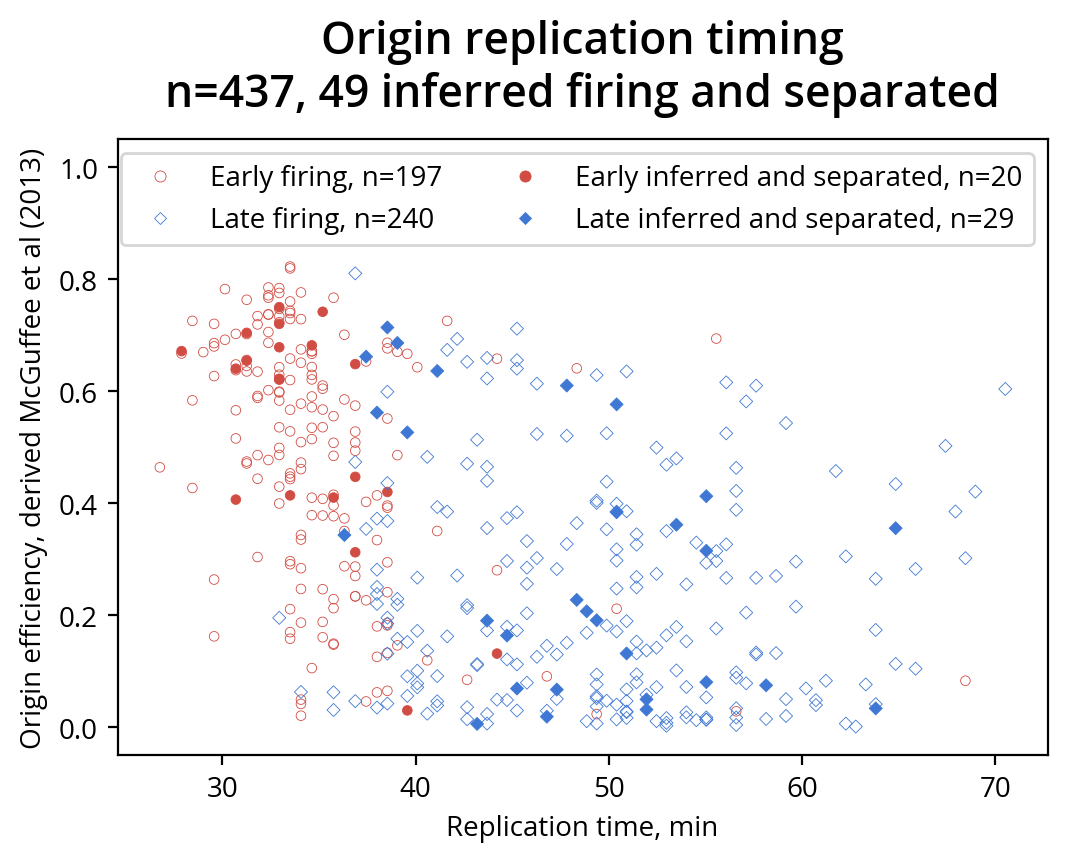

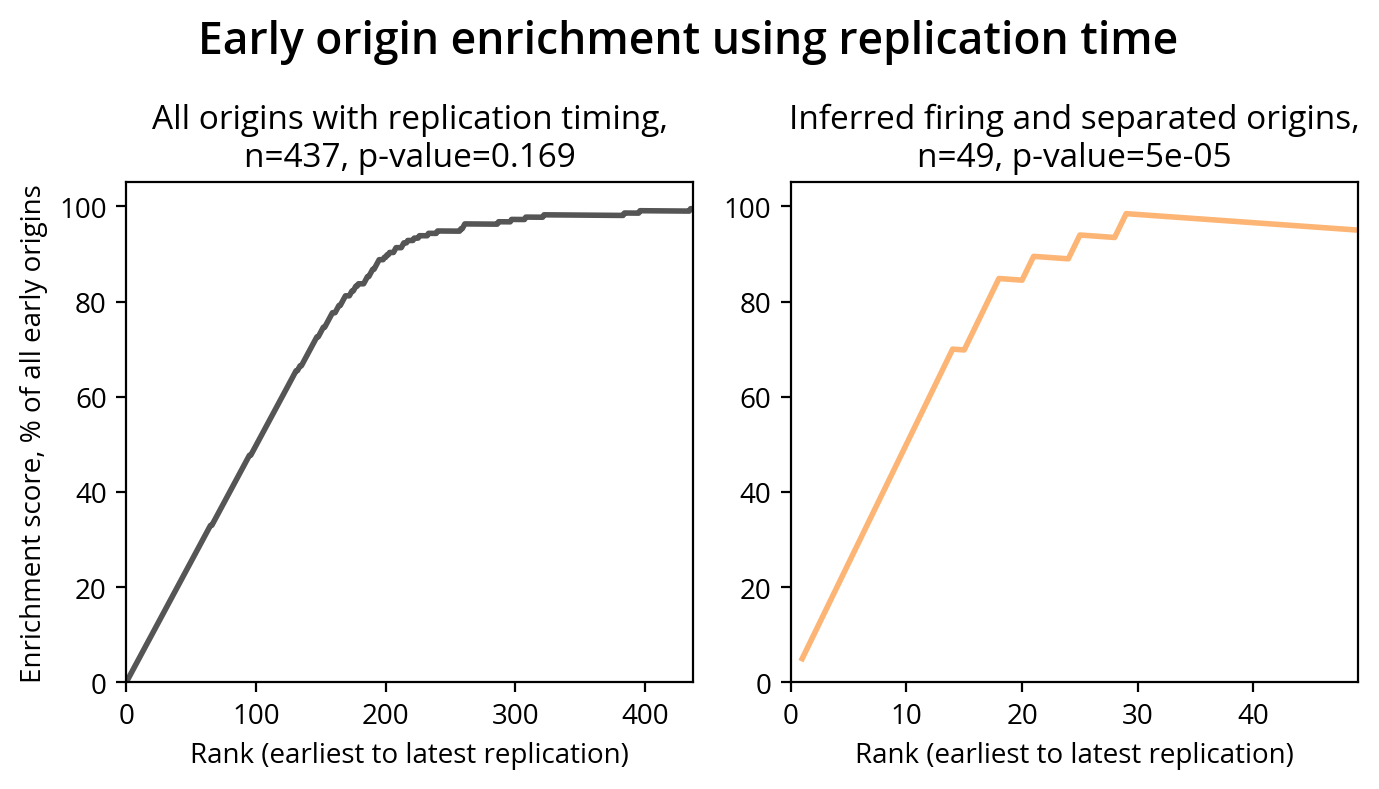

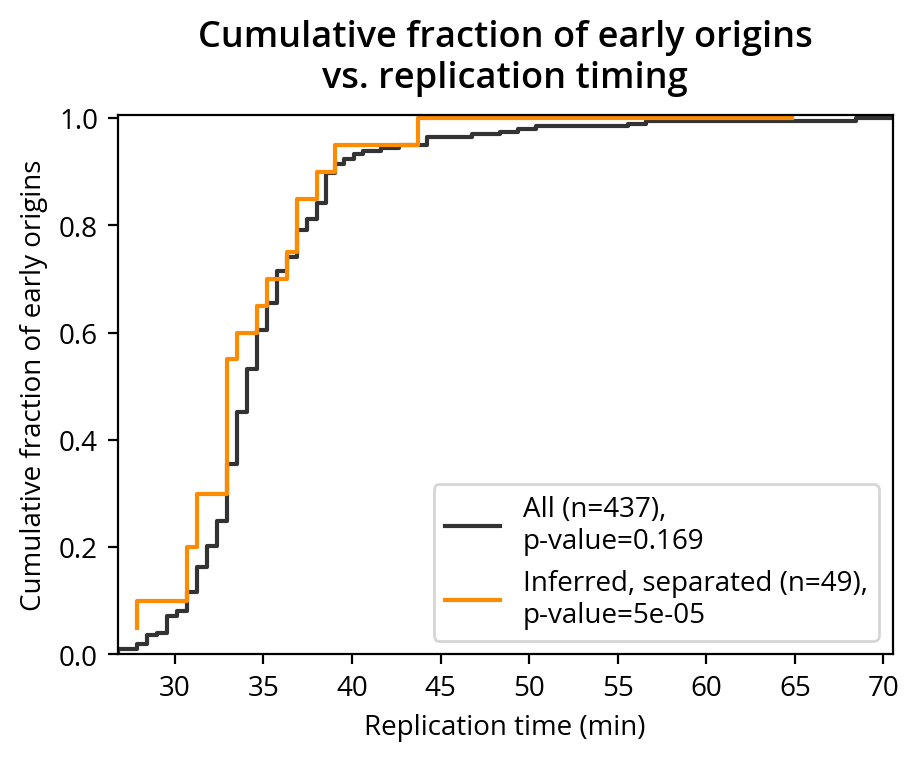

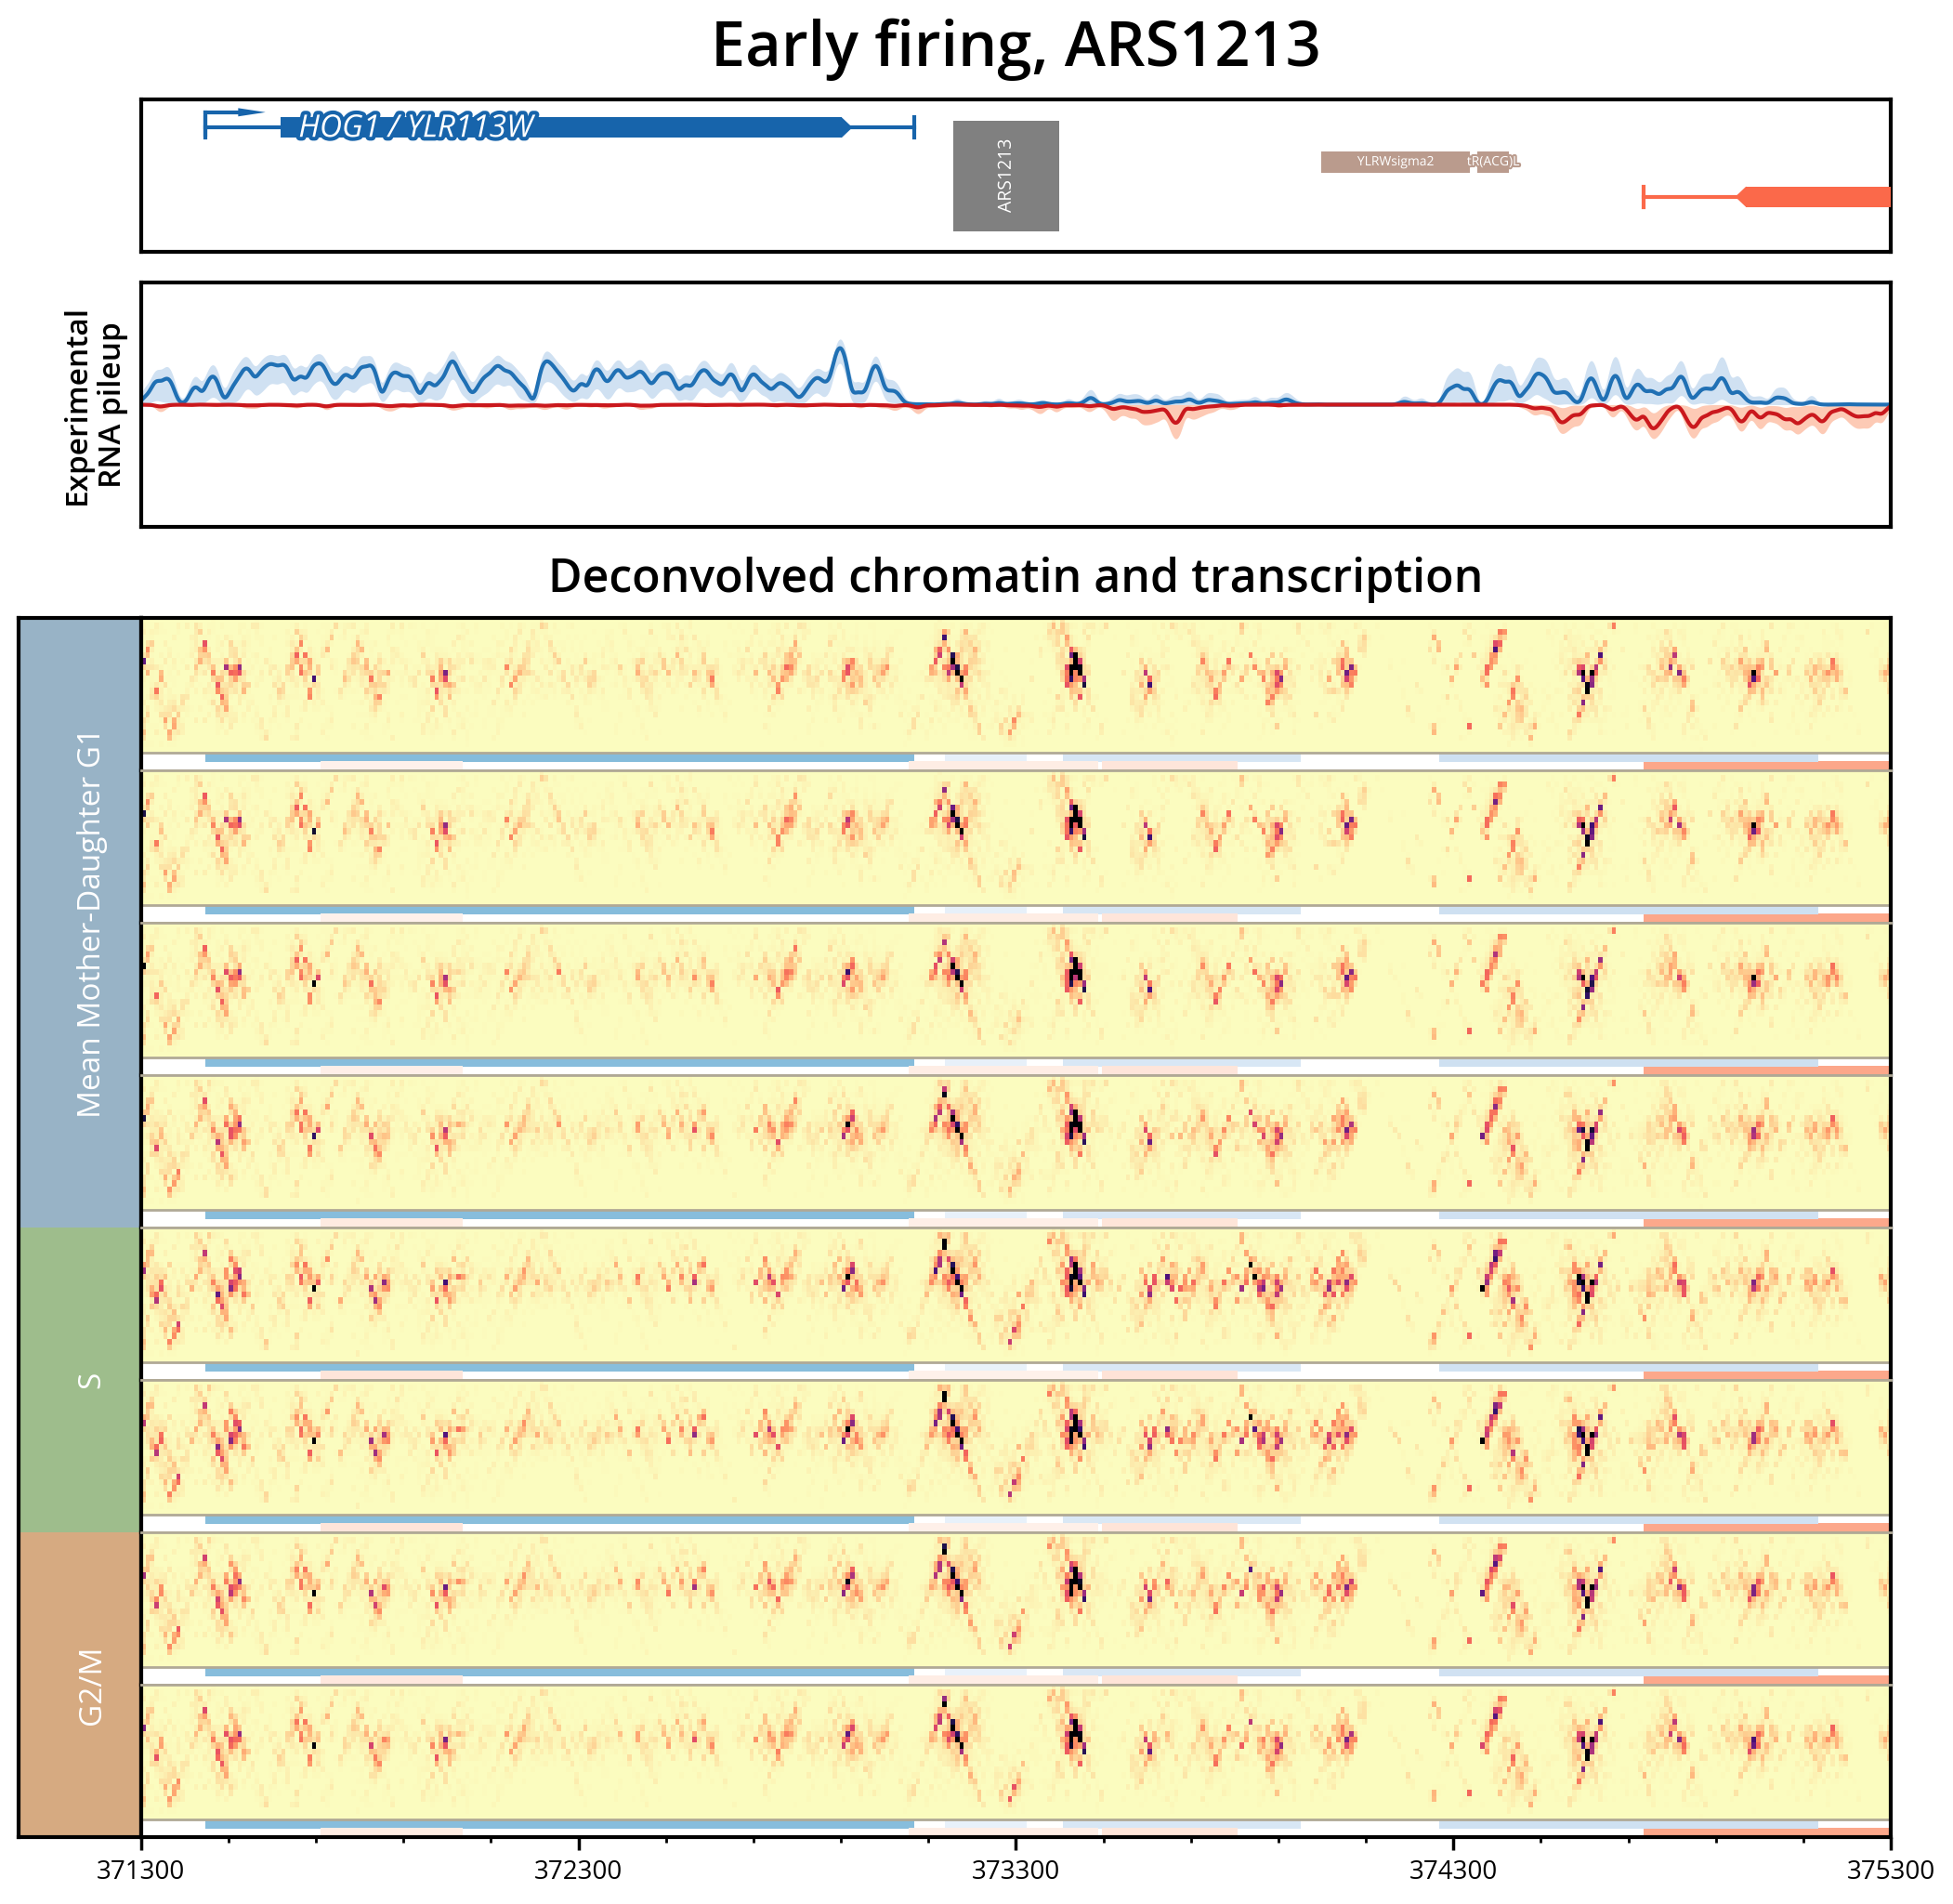

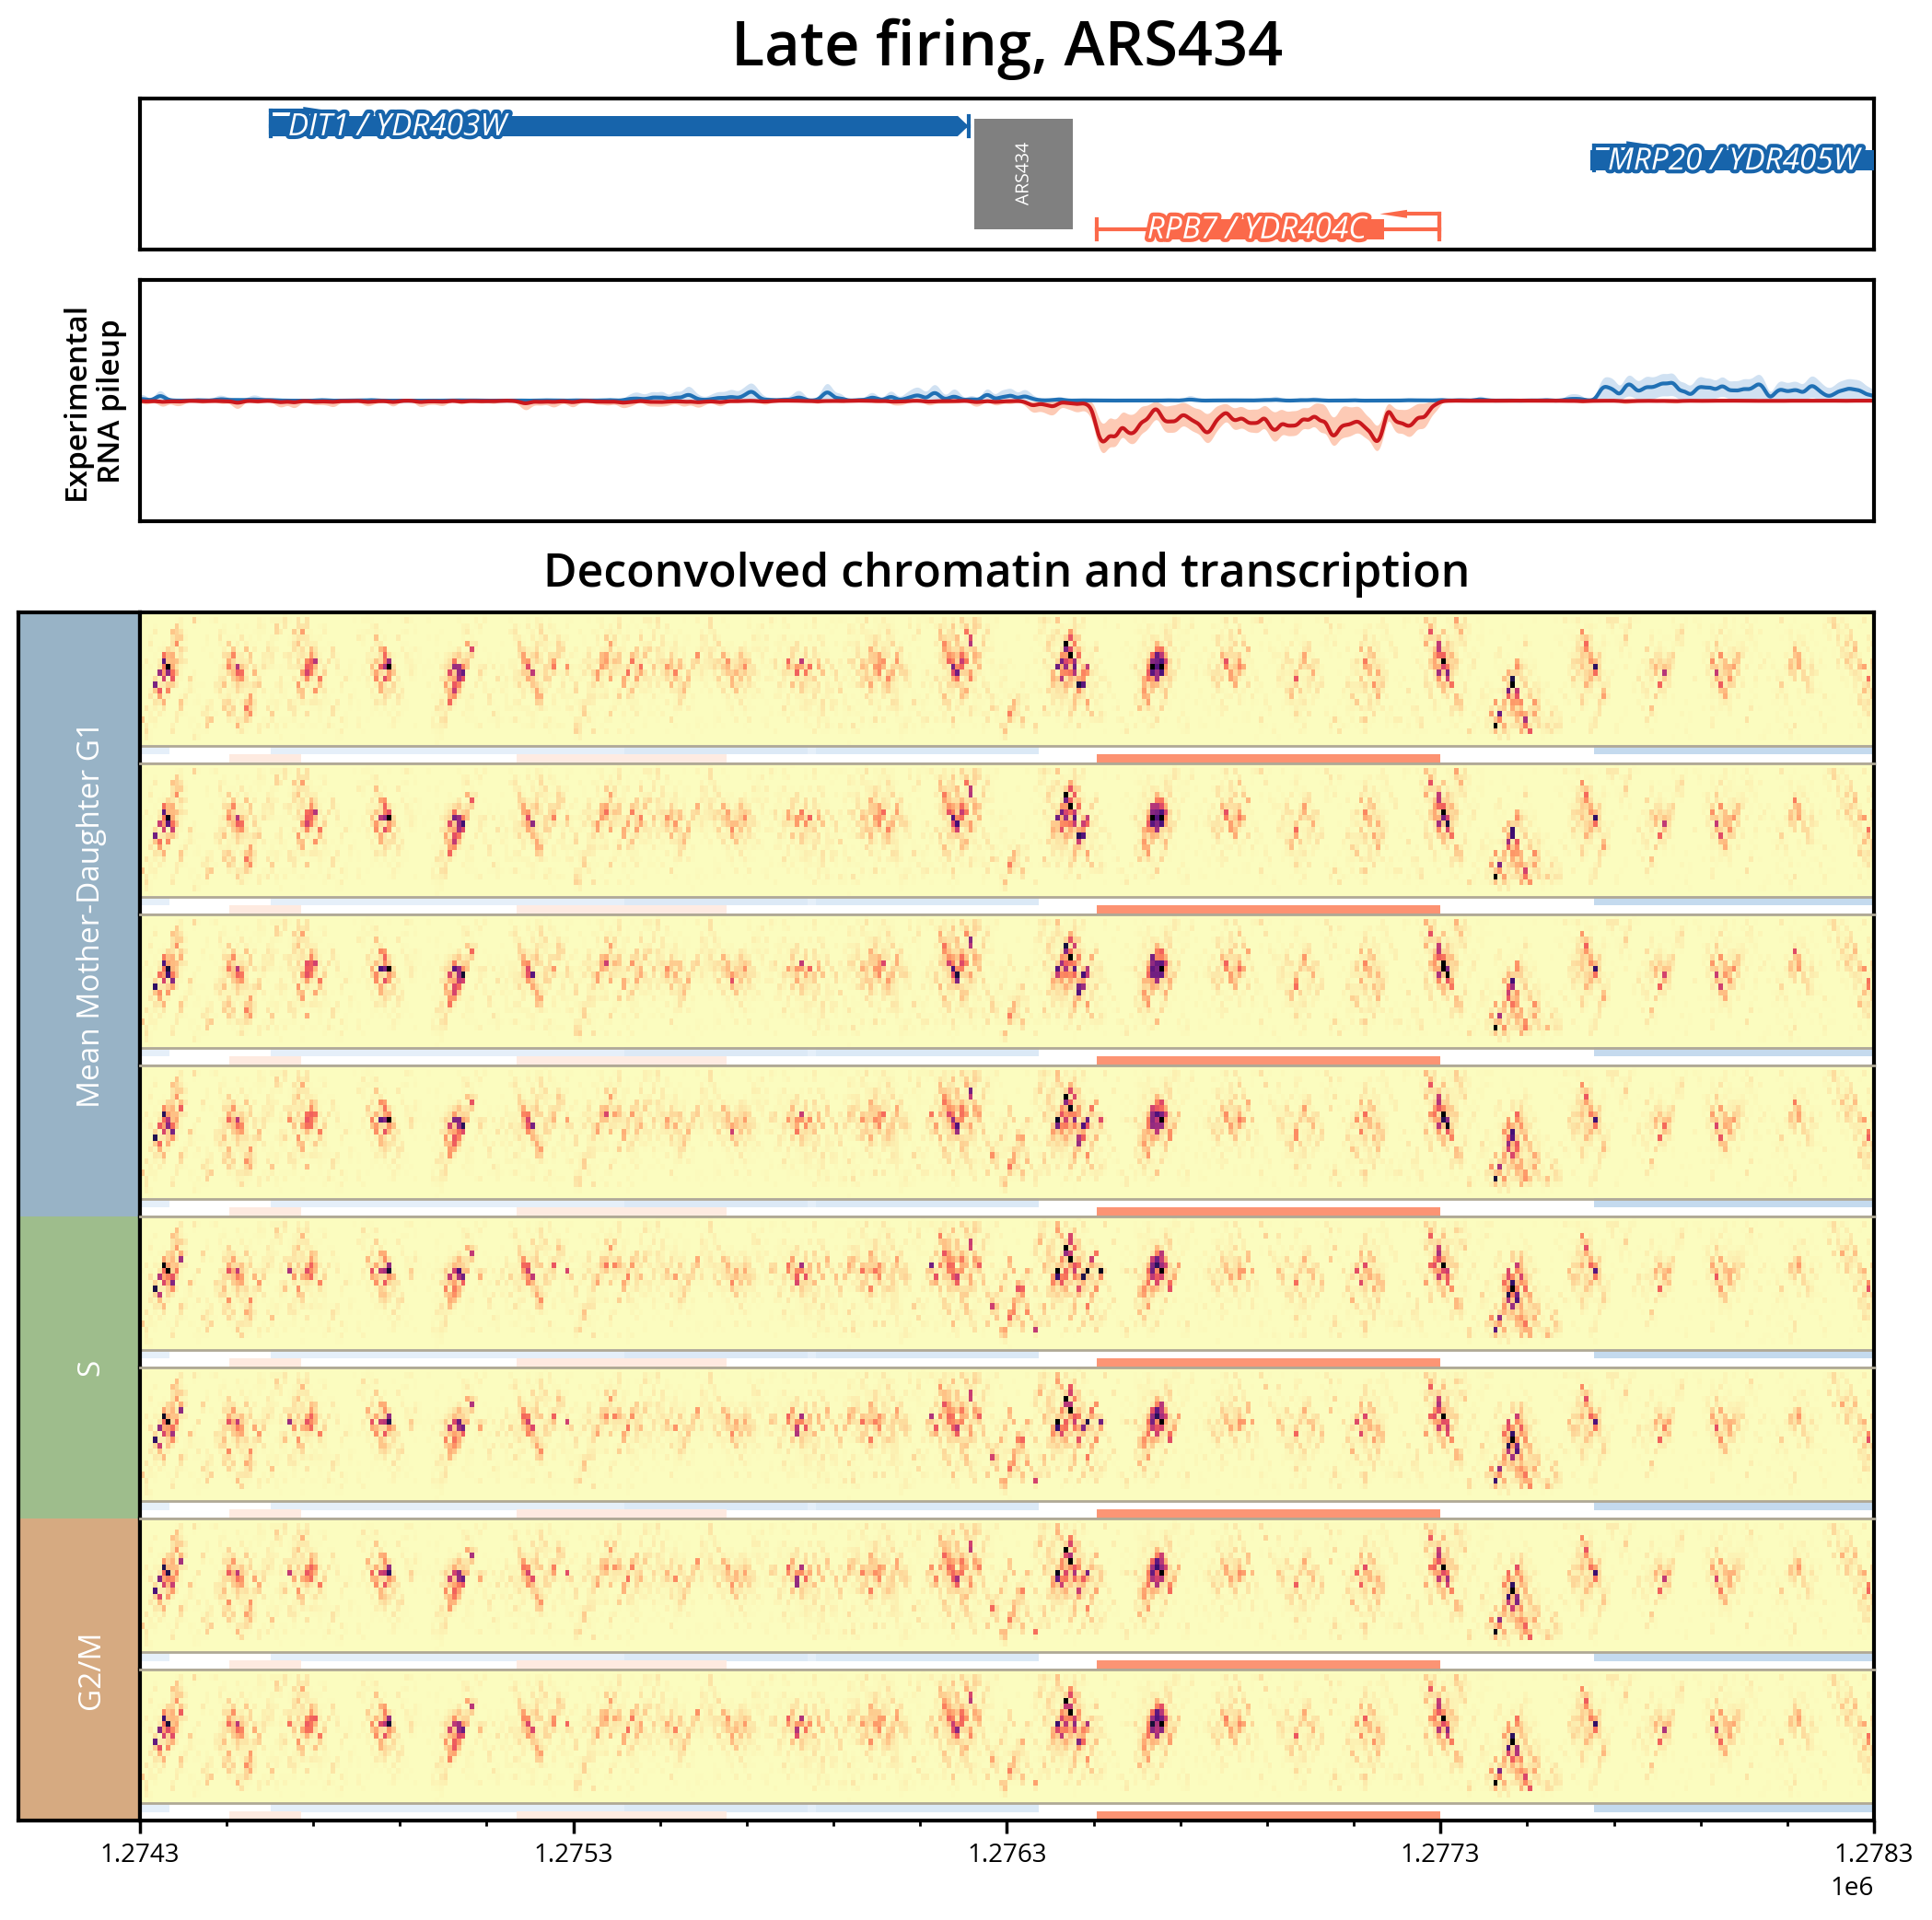

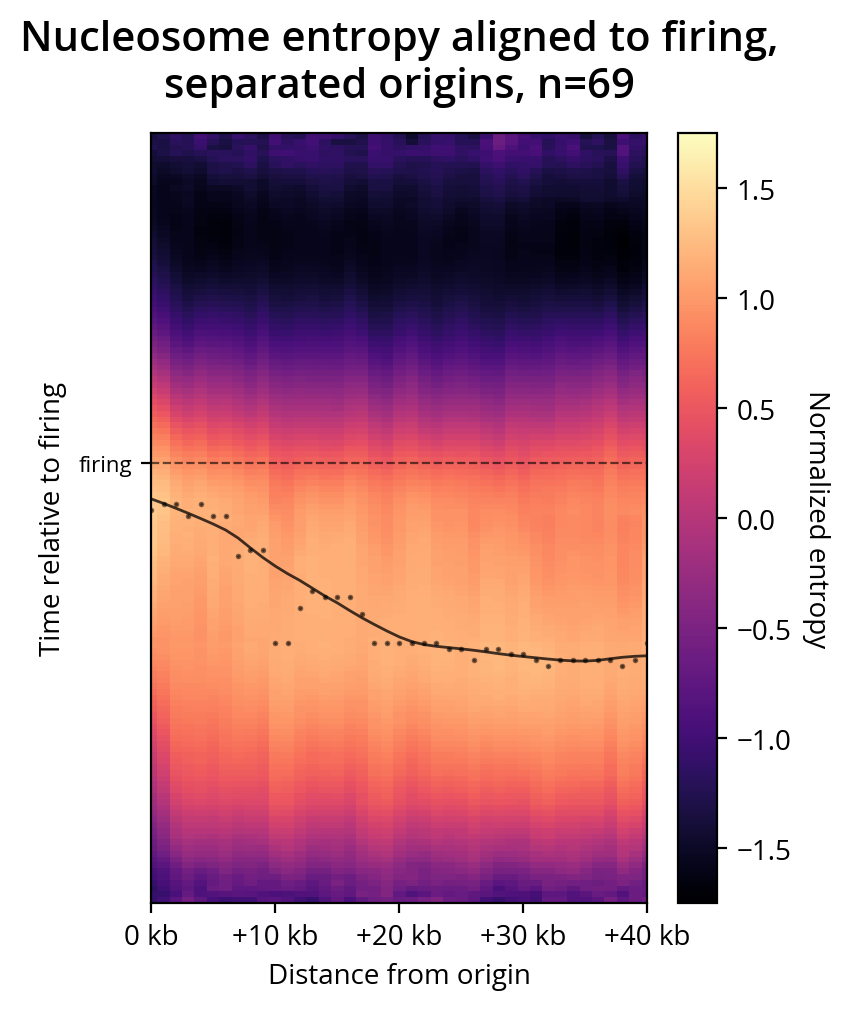

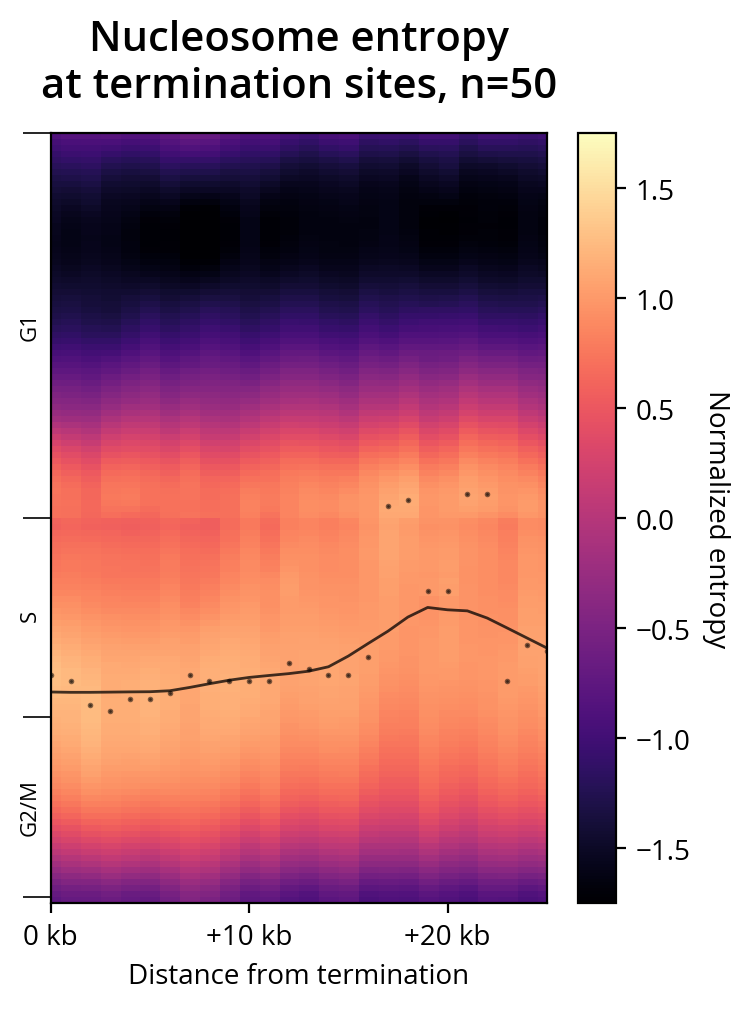

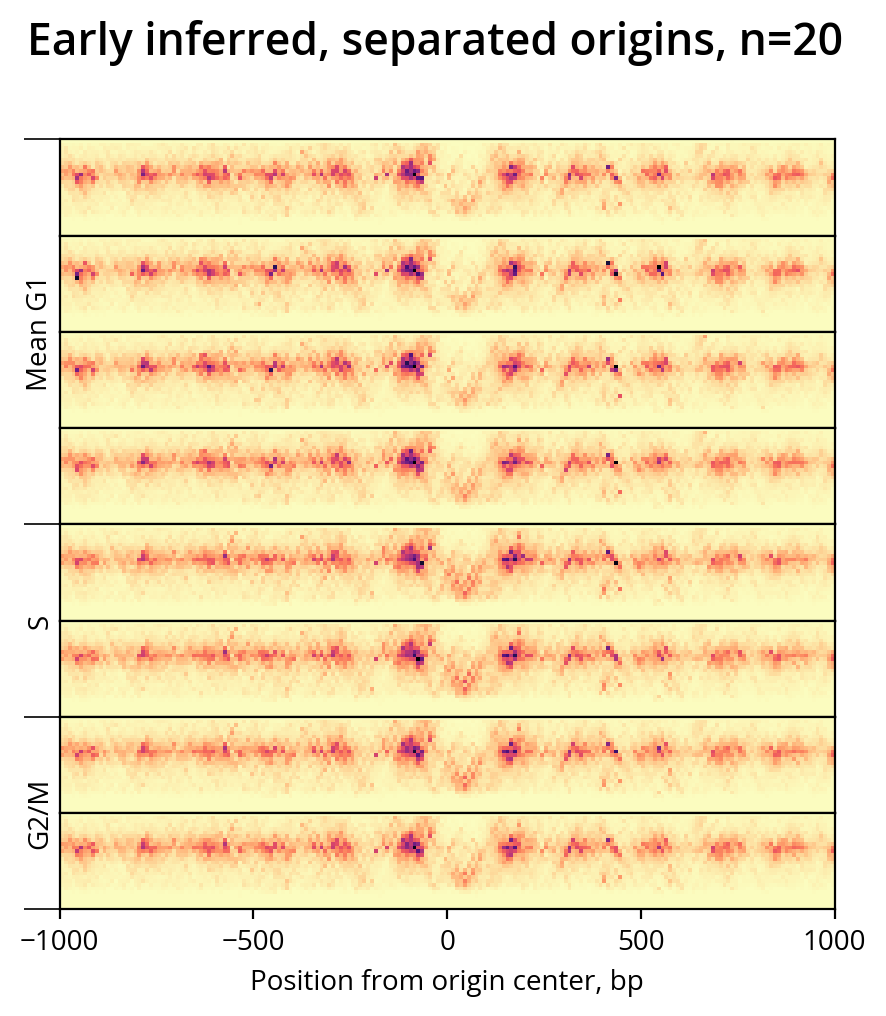

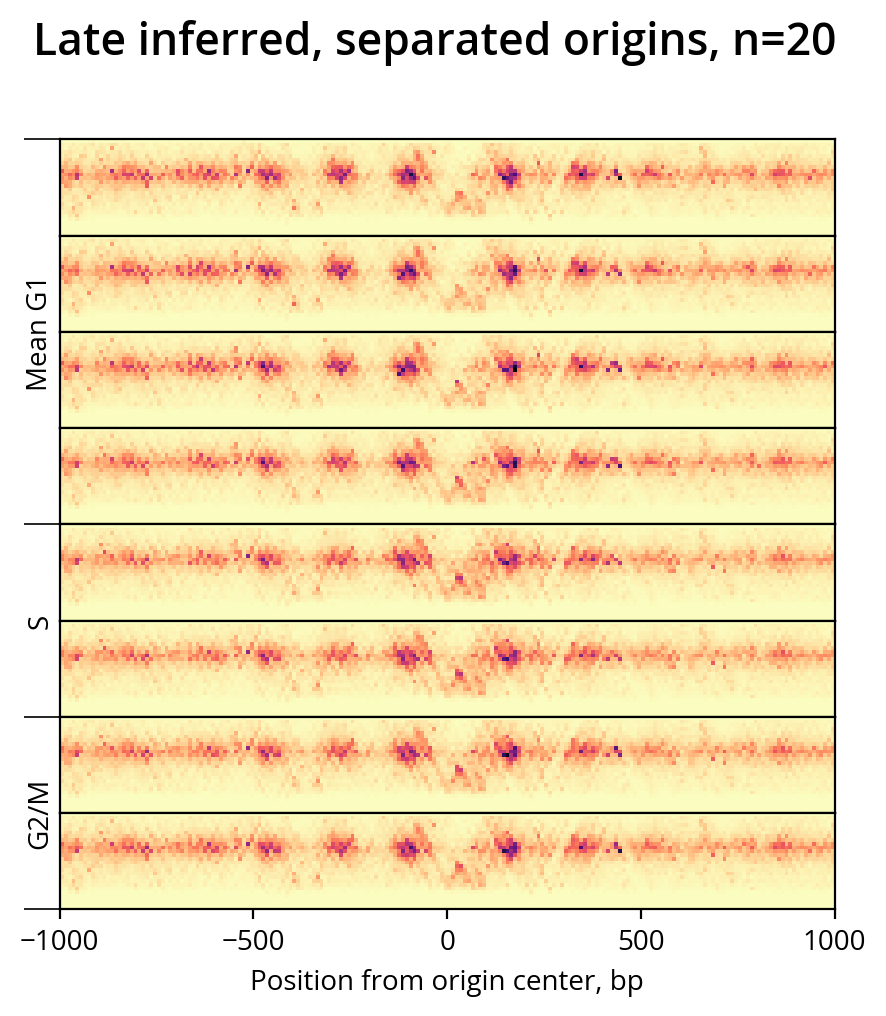

In [45]:
fig_origins.plot_all()

Debug figure saved to: output/draft4_run//Figures/Debug/Supplemental2.7_Replication_Origins_Validation_debug.png
Clean figure saved to: output/draft4_run//Figures/Supplemental2.7_Replication_Origins_Validation.png
Uppercase figure saved to: output/draft4_run//Figures/Uppercase/Supplemental2.7_Replication_Origins_Validation.png


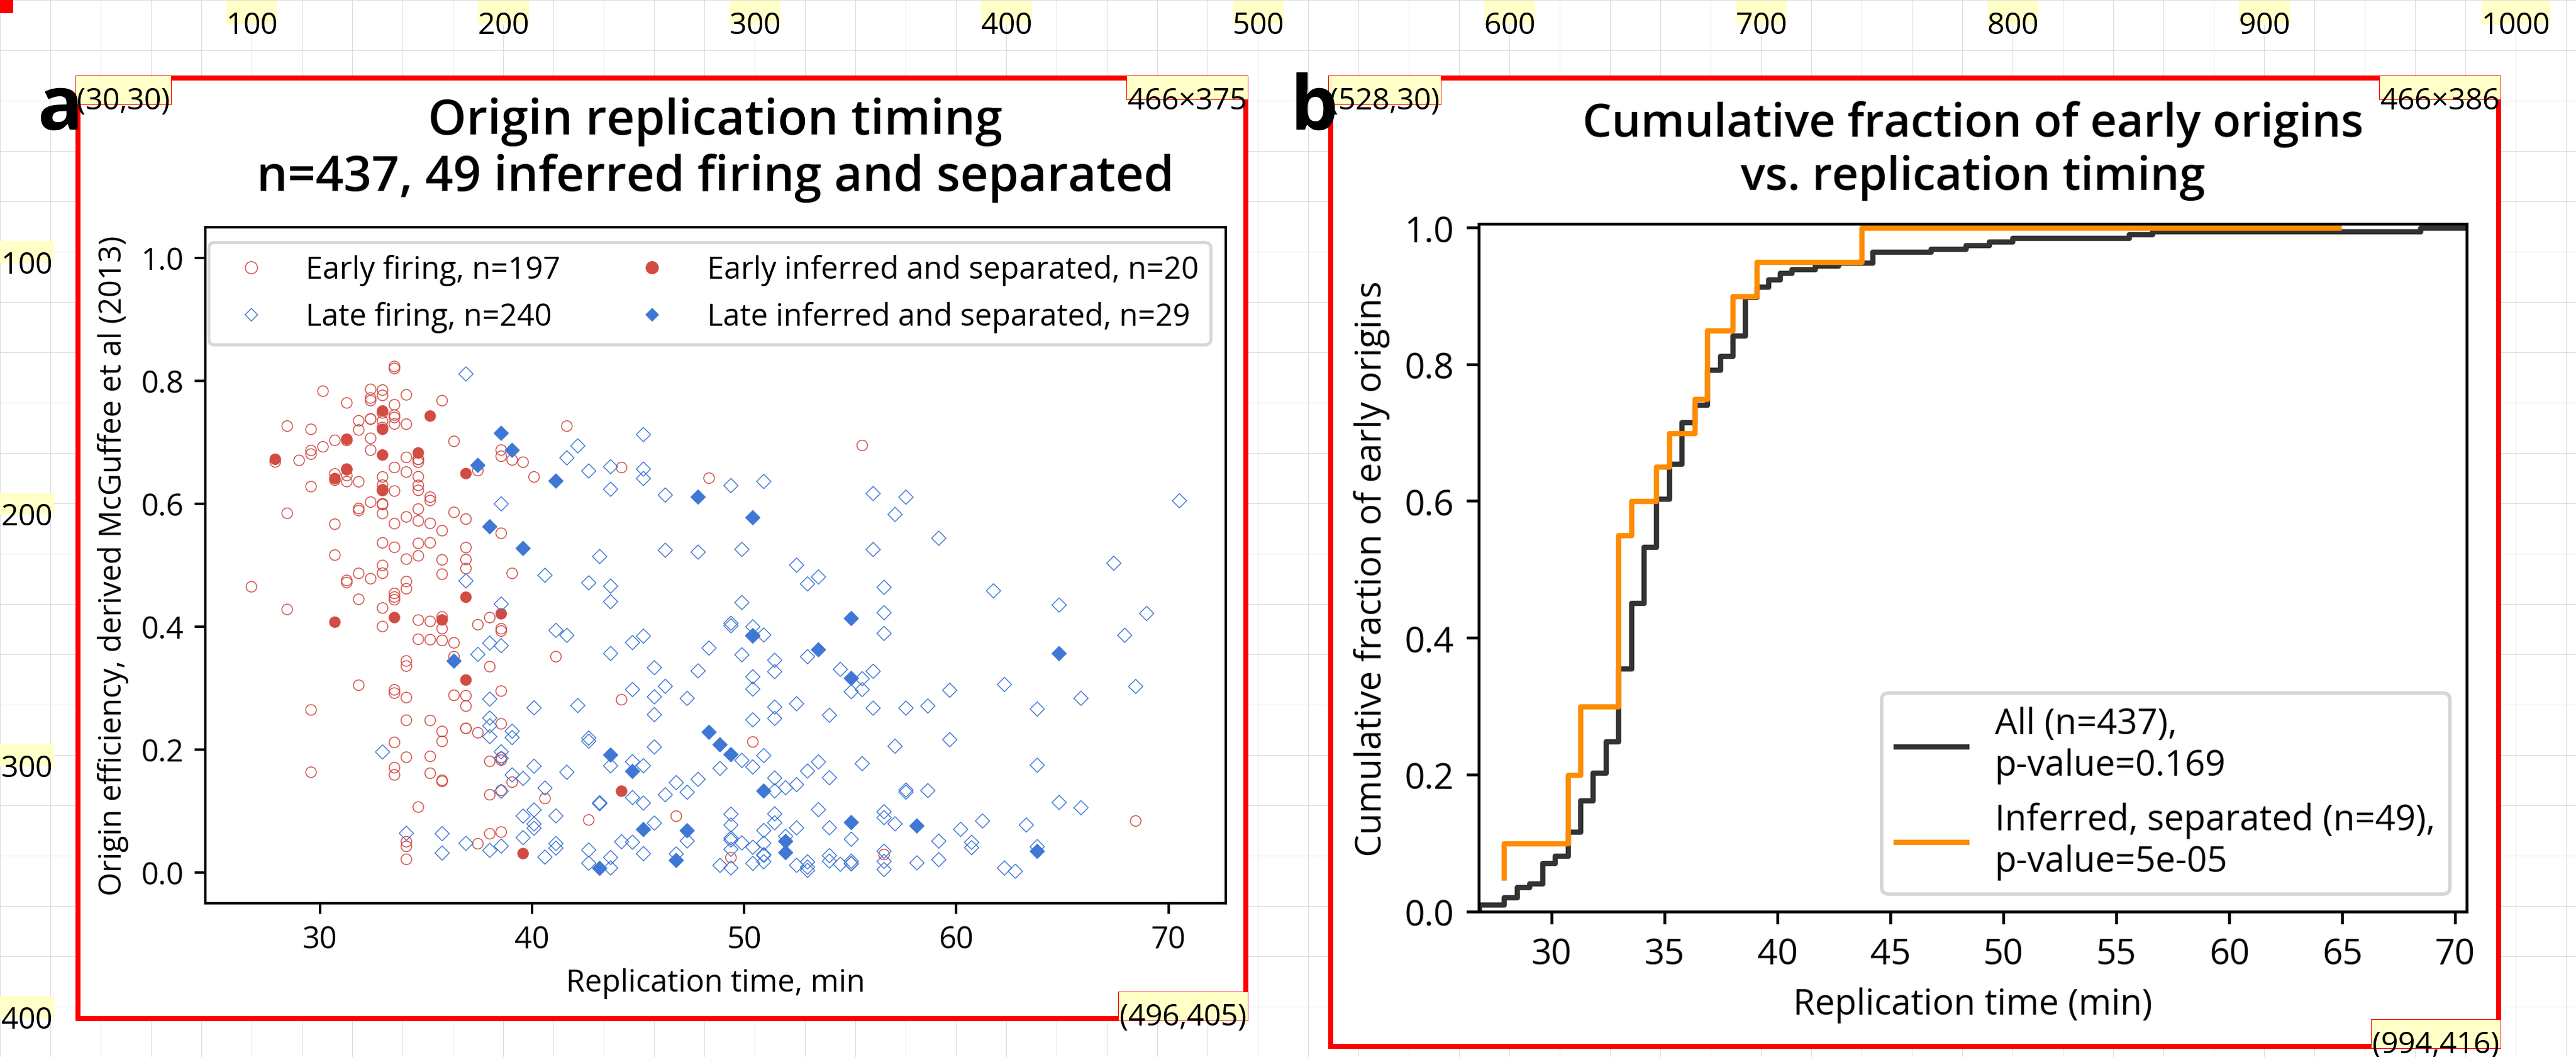

In [5]:
from IPython.display import Image, display

fig_origins.layout_supplemental_replication_origins_validation()
display(Image('output/draft4_run/Figures/Debug/Supplemental2.7_Replication_Origins_Validation_debug.png'))


In [ ]:
fig_origins.prepare_footprint_analysis()

Saved figure to: output/draft4_run//figure_origins/early_composite_g1_g2.png
Saved figure to: output/draft4_run//figure_origins/late_composite_g1_g2.png
Saved figure to: output/draft4_run//figure_origins/maxg1_footprint_boxplots.png
retrieve -40.5379
Saved figure to: output/draft4_run//figure_origins/all_branches_footprint.png


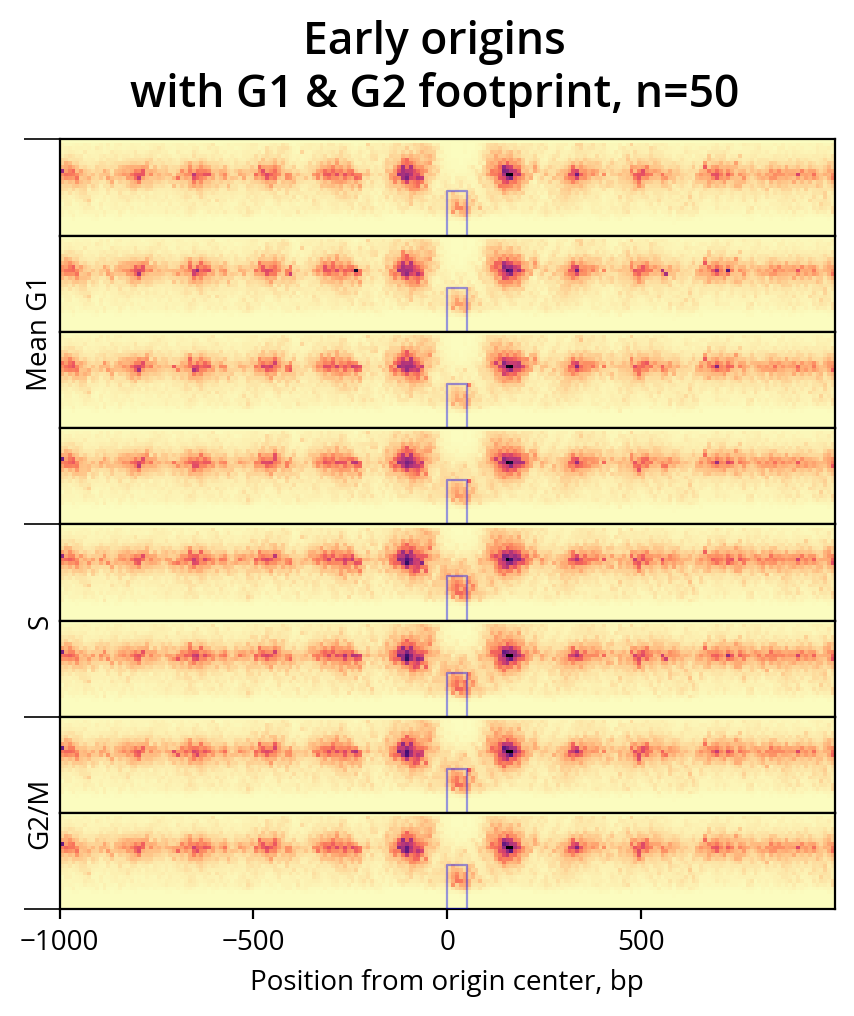

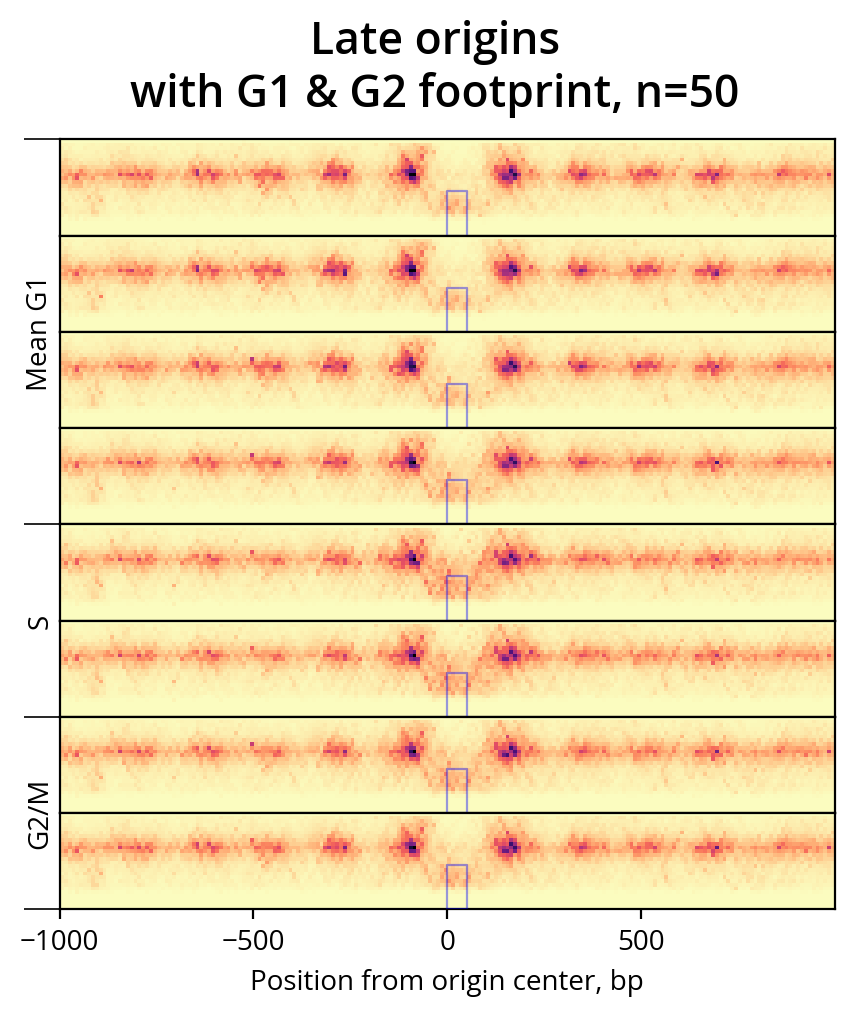

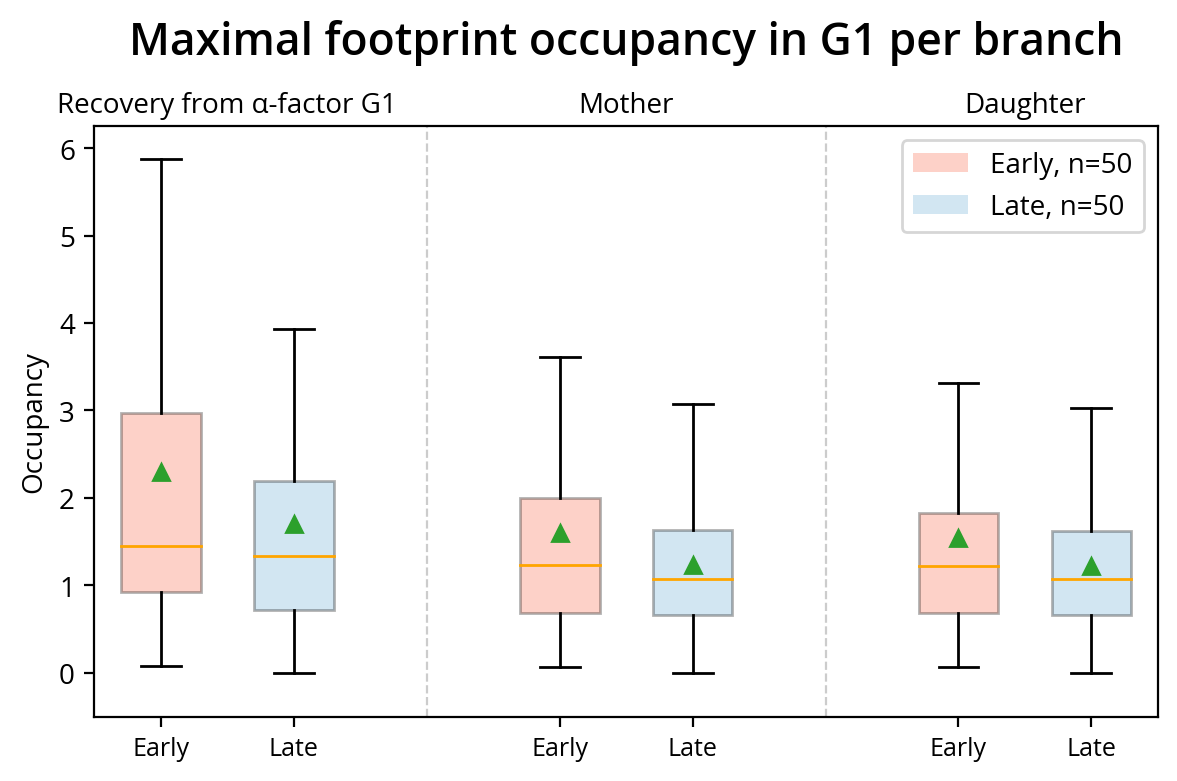

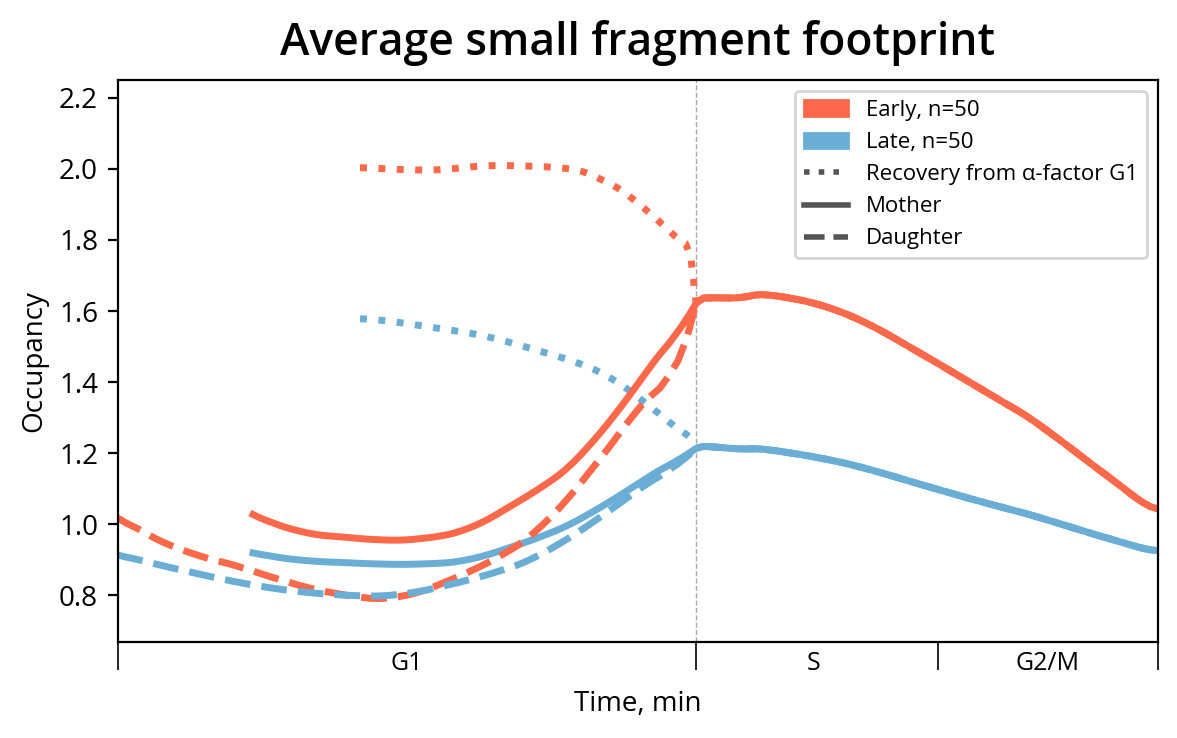

In [100]:
fig_origins.plot_footprint_analysis()

Debug figure saved to: output/draft4_run//Figures/Debug/Supplemental4.2_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/Supplemental4.2_Origins.png
Uppercase figure saved to: output/draft4_run//Figures/Uppercase/Supplemental4.2_Origins.png


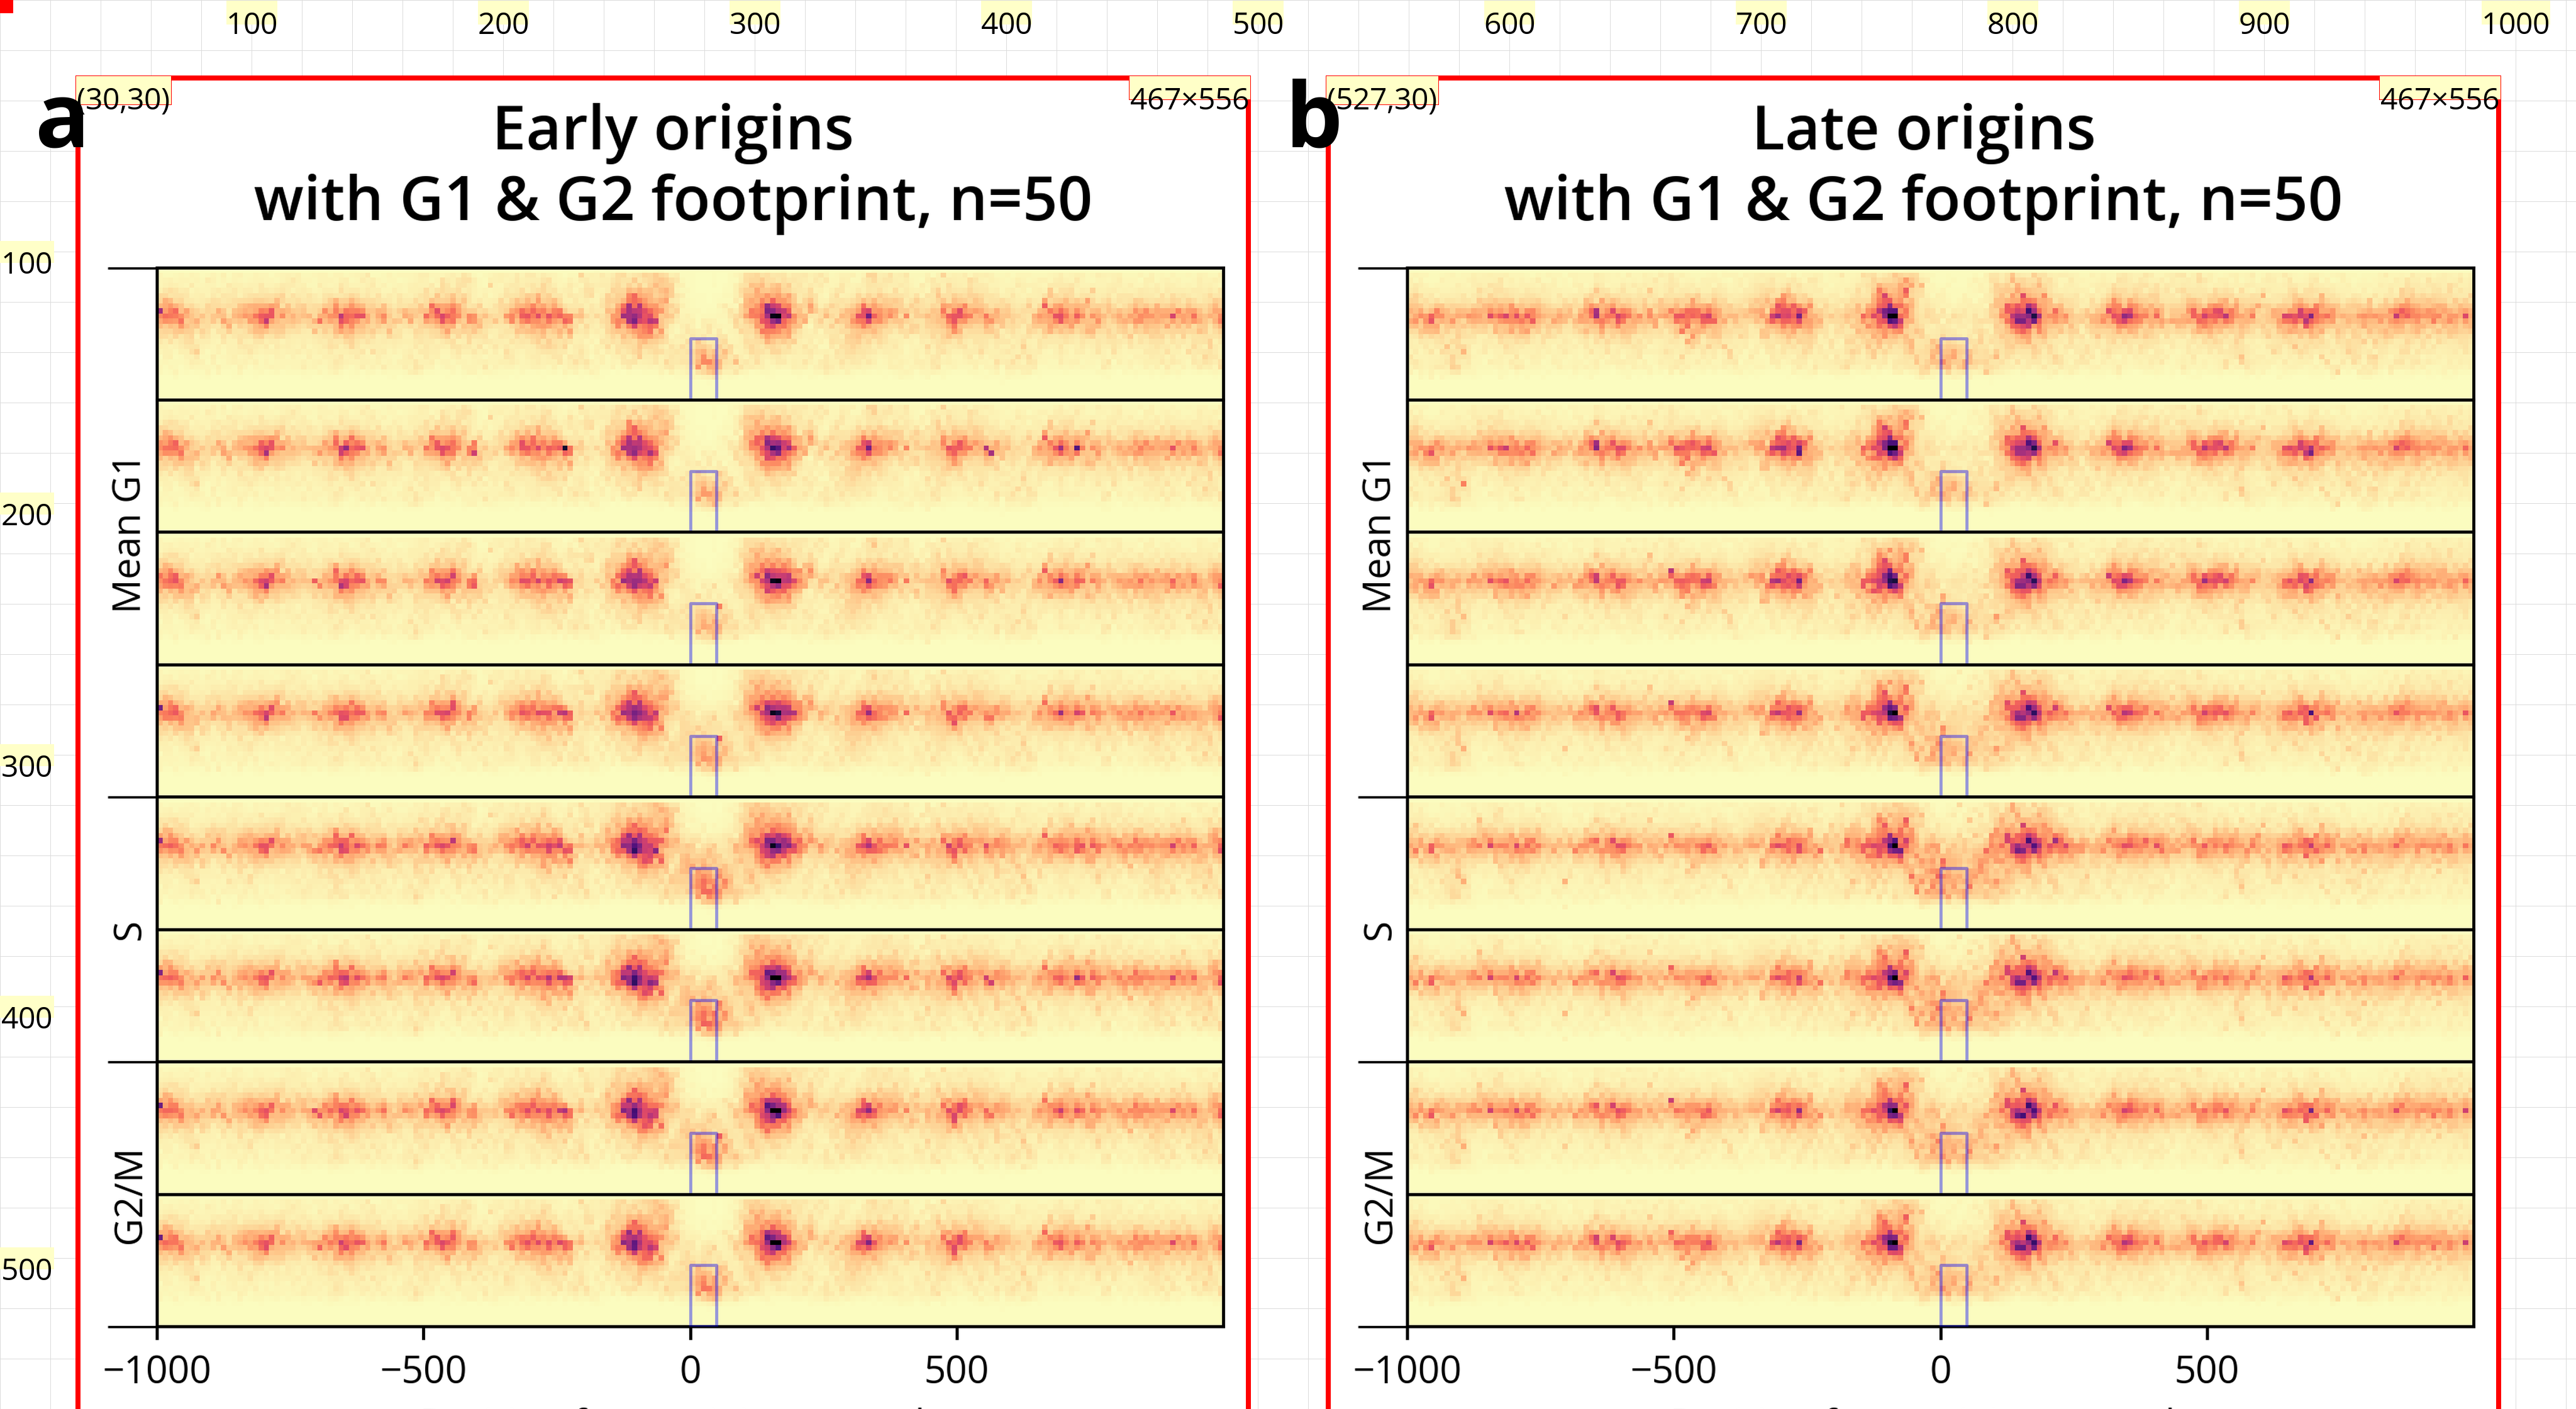

In [9]:
fig_origins.layout_supplemental_panel()
display(Image('output/draft4_run/Figures/Debug/Supplemental4.2_Origins_debug.png'))

Saved figure to: output/draft4_run//figure_origins/early_composite_g1_g2.png
Saved figure to: output/draft4_run//figure_origins/late_composite_g1_g2.png
Saved figure to: output/draft4_run//figure_origins/maxg1_footprint_boxplots.png
retrieve -40.5379
Saved figure to: output/draft4_run//figure_origins/all_branches_footprint.png


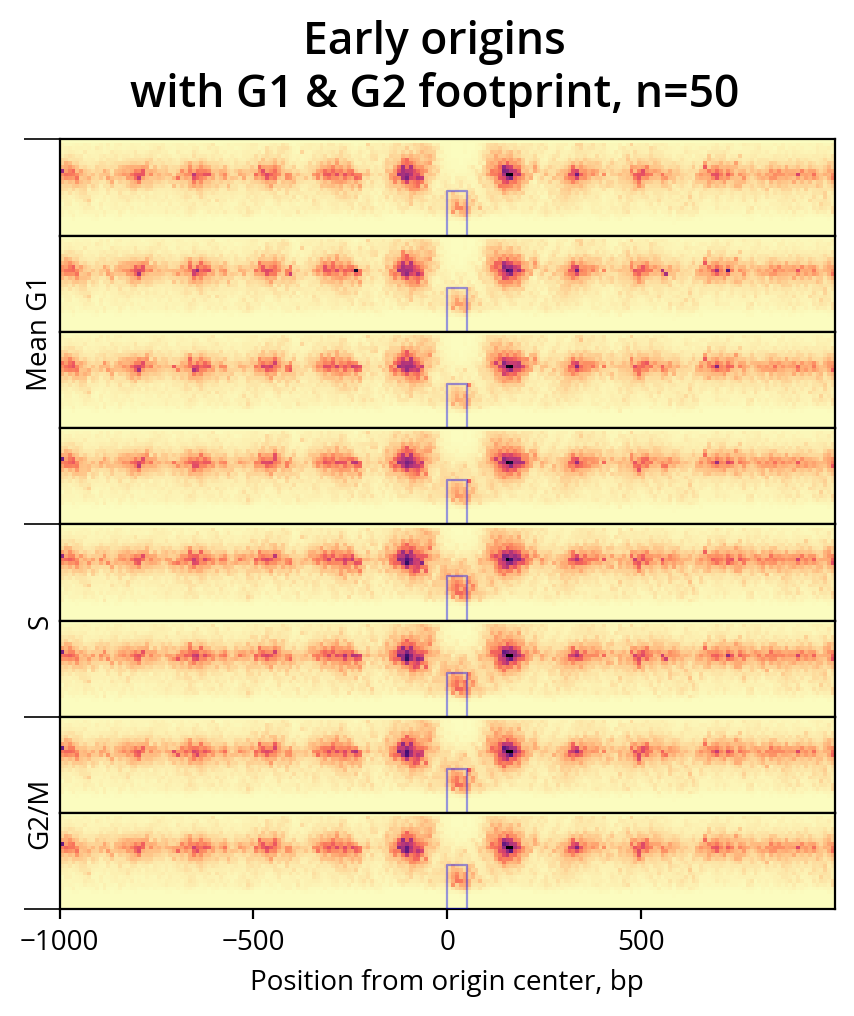

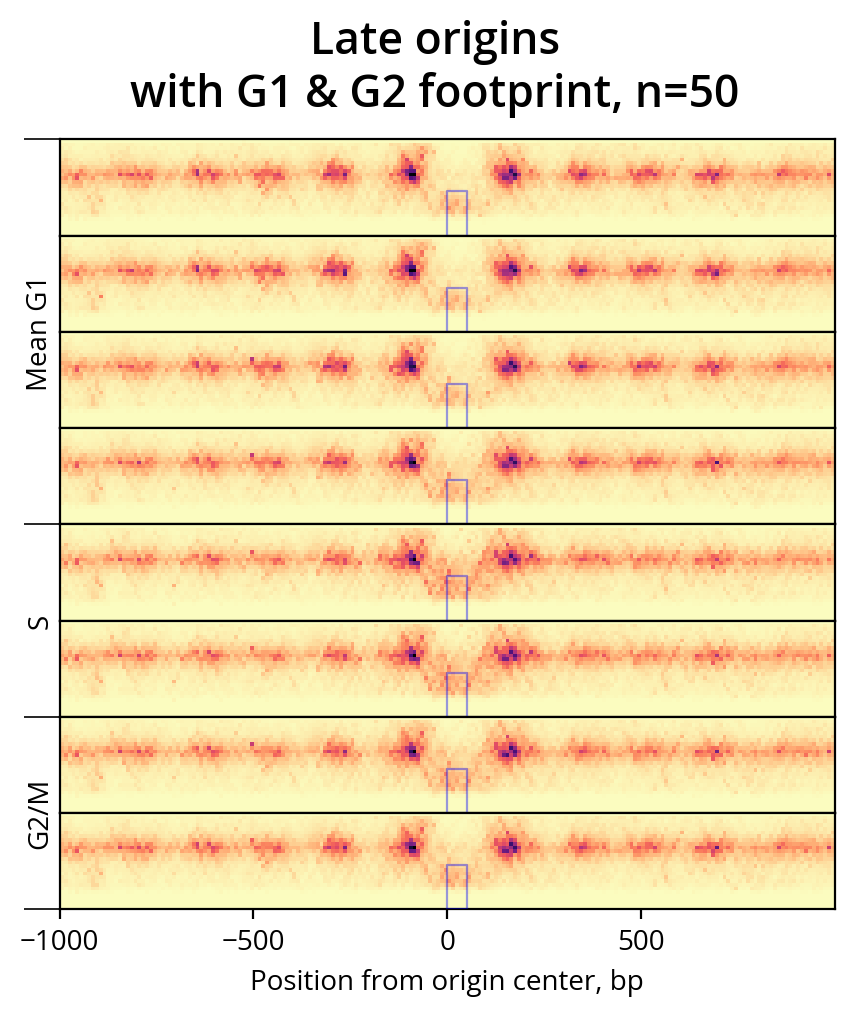

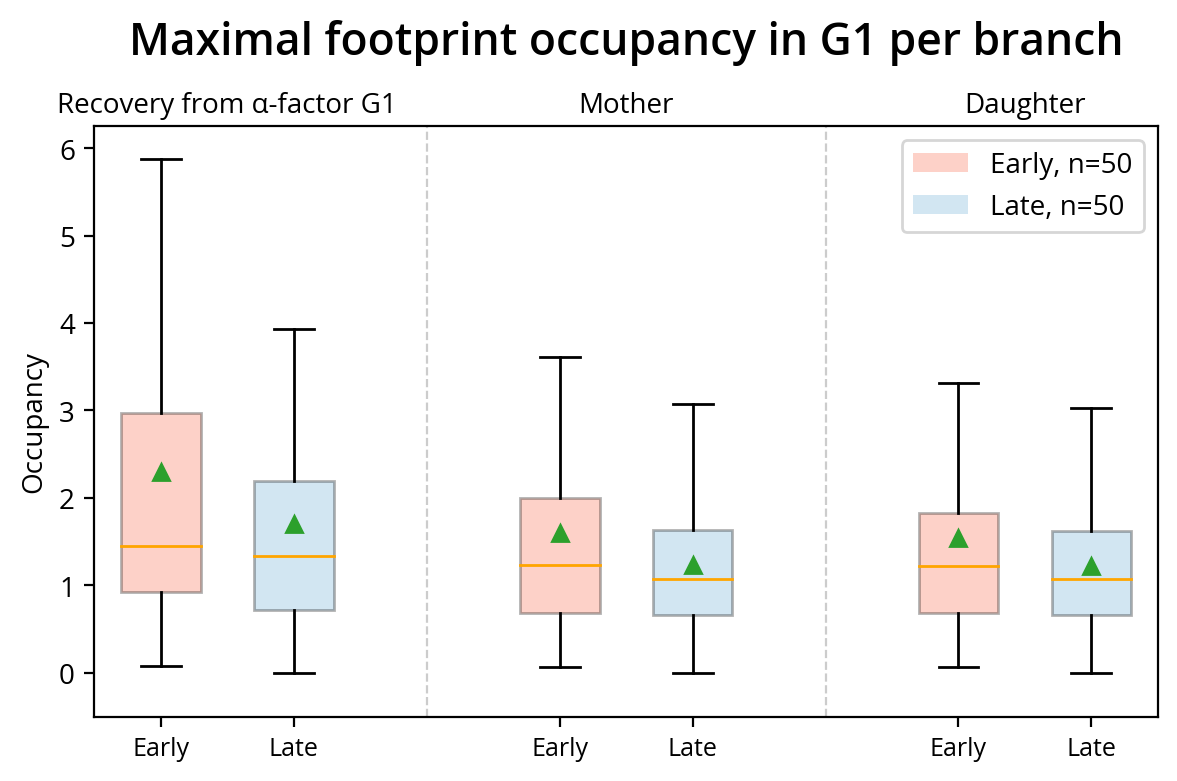

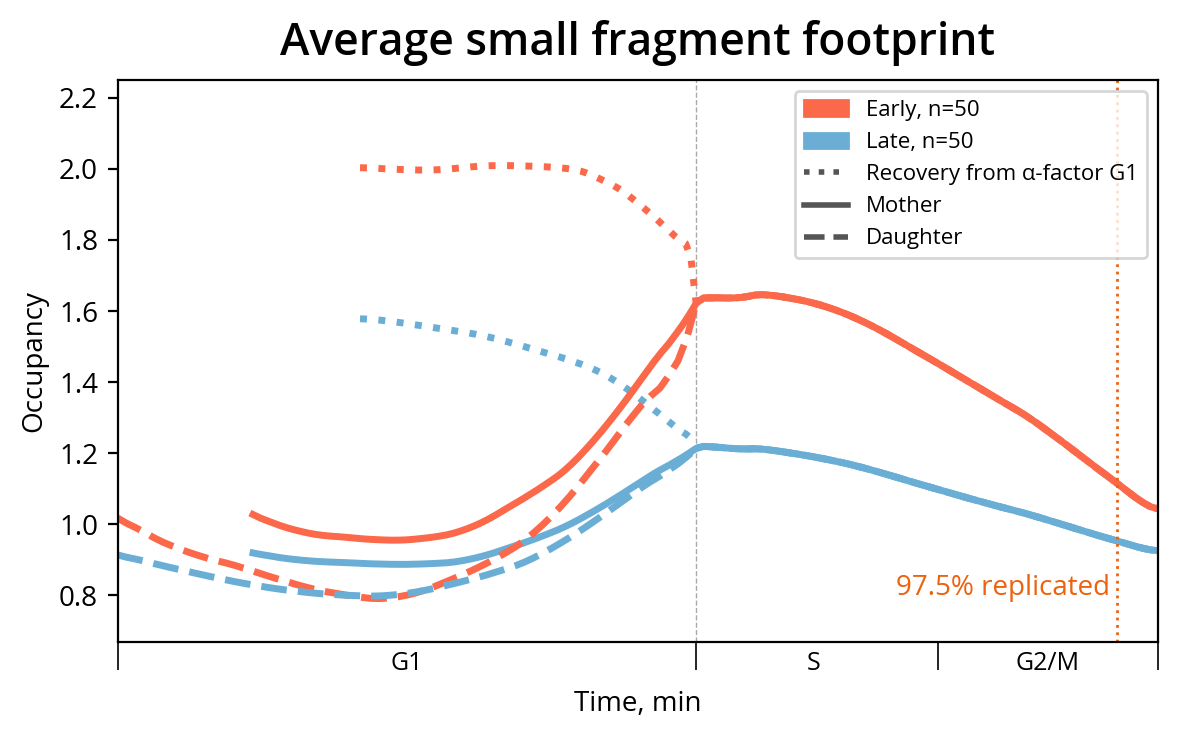

In [131]:
fig_origins.plot_footprint_analysis()

Debug figure saved to: output/draft4_run//Figures/Debug/Figure4_Origins_debug.png
Clean figure saved to: output/draft4_run//Figures/Figure4_Origins.png
Uppercase figure saved to: output/draft4_run//Figures/Uppercase/Figure4_Origins.png


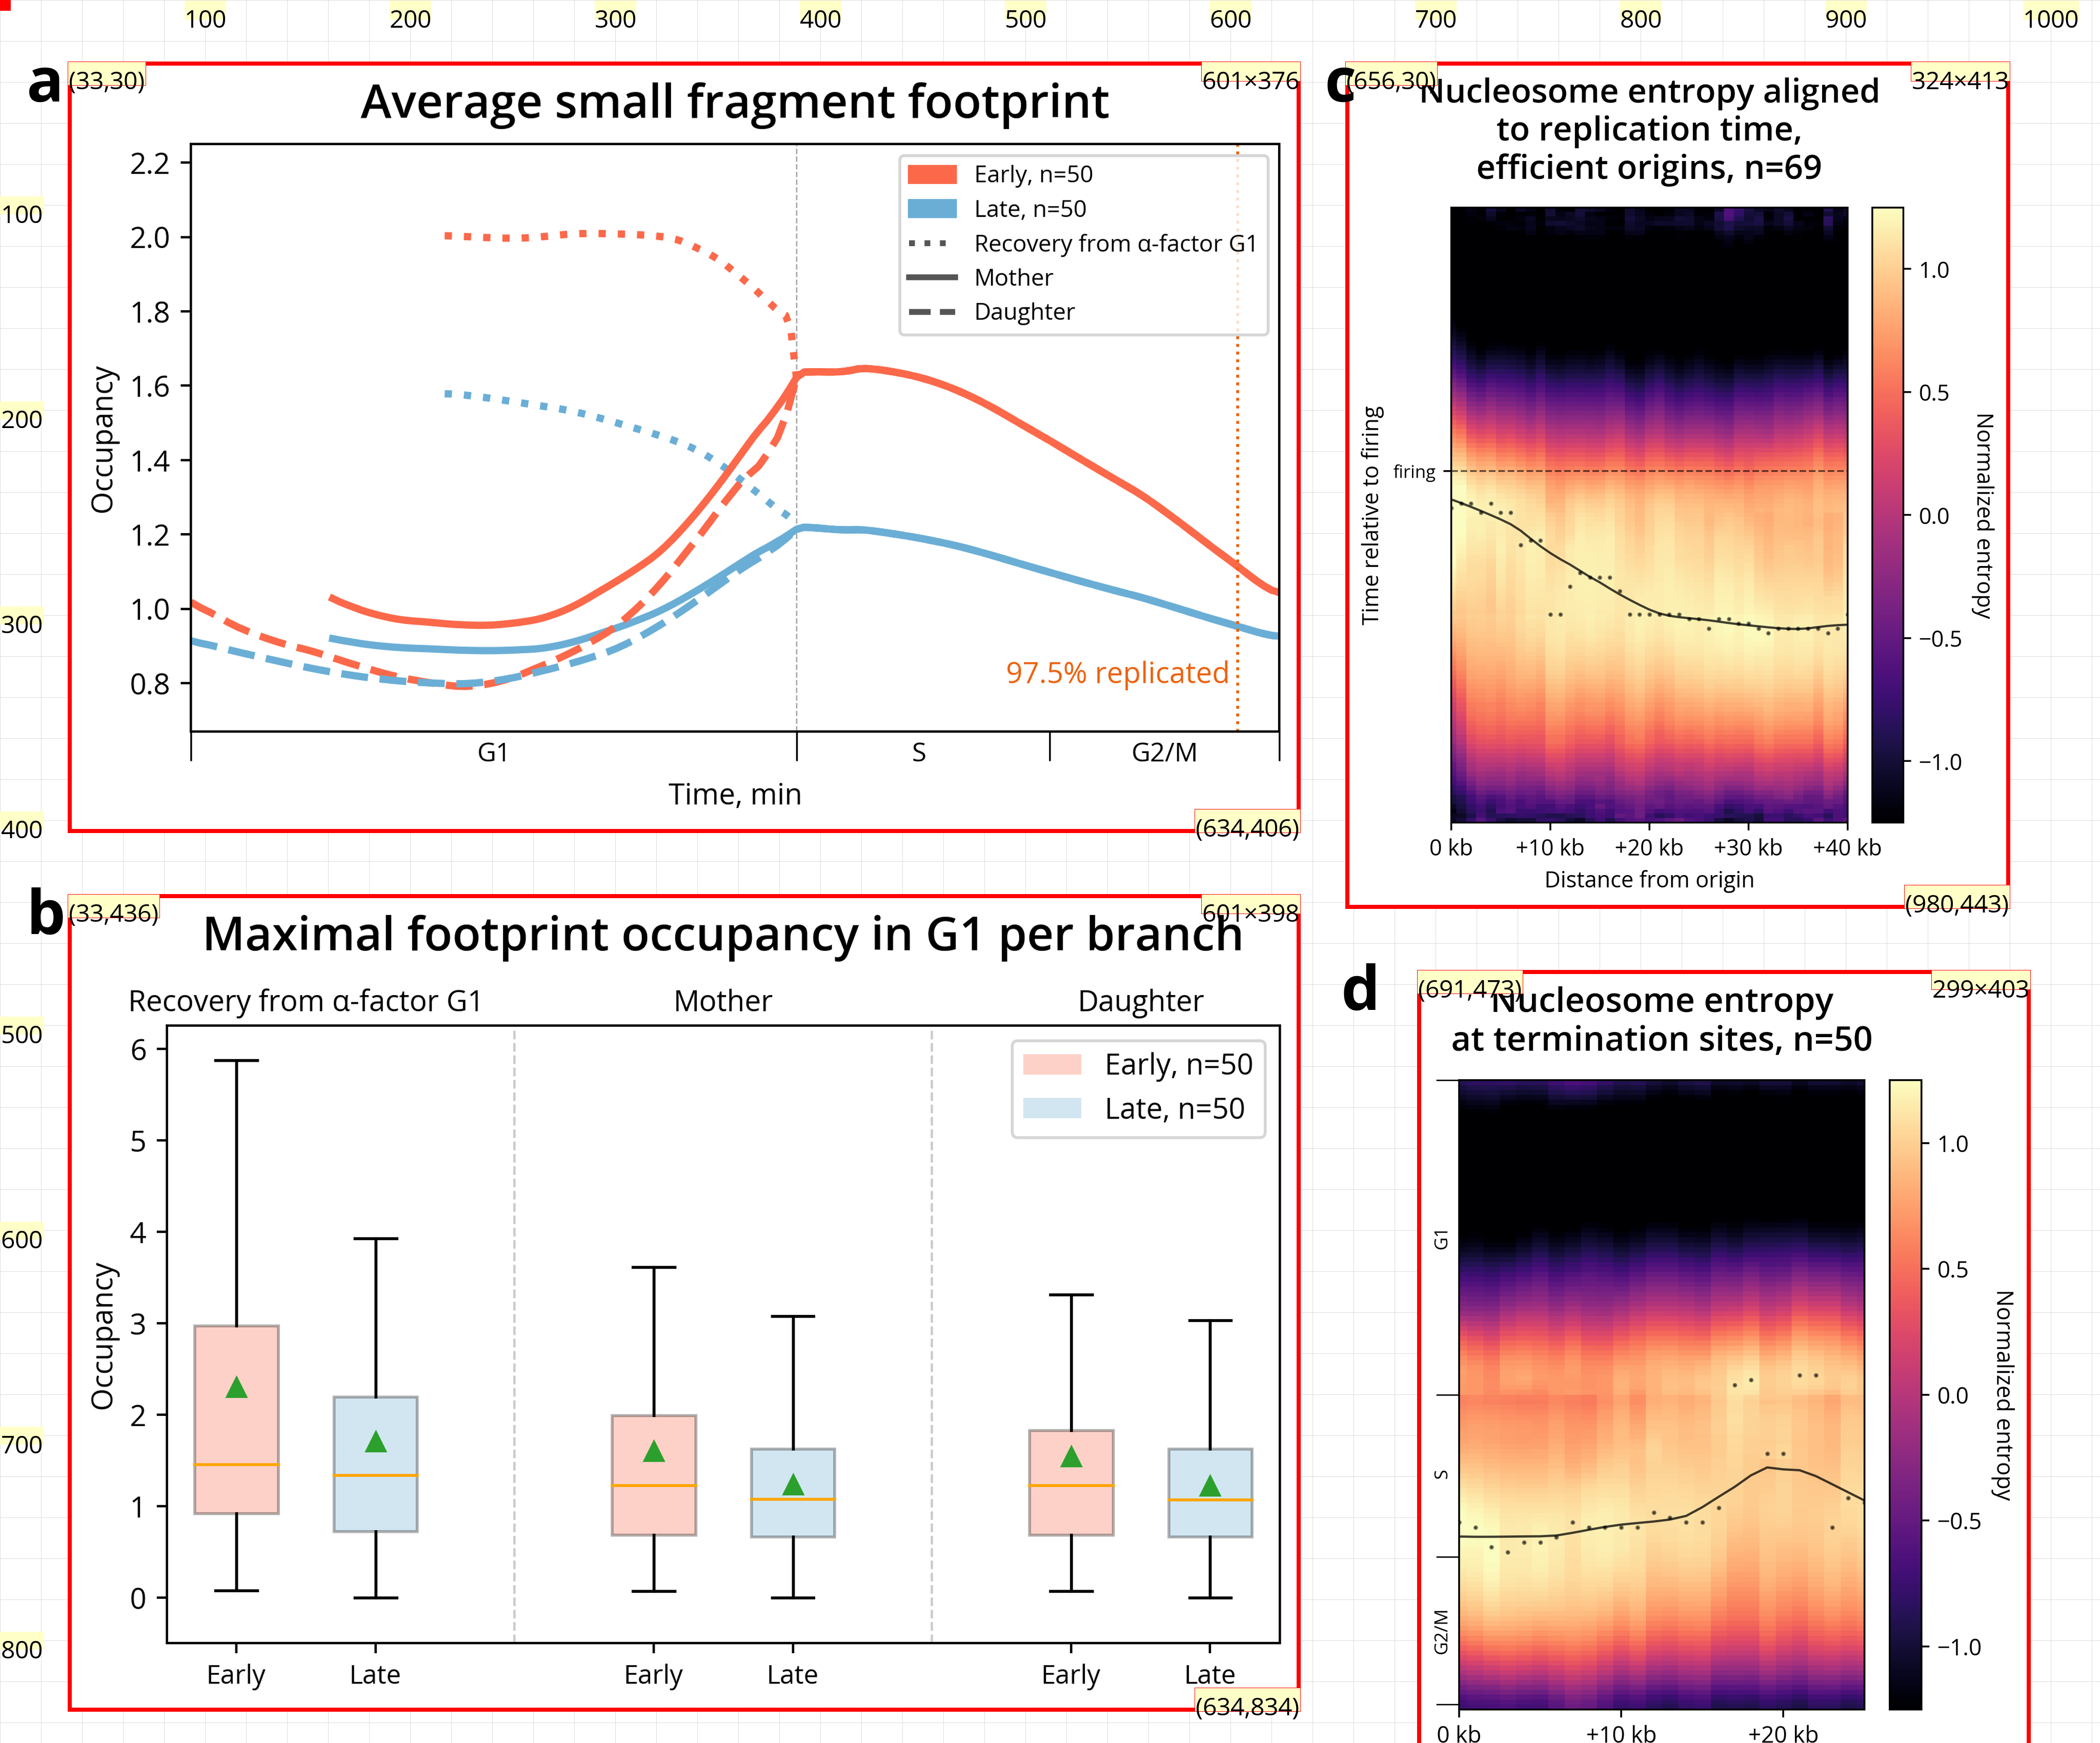

In [132]:
fig_origins.layout_panel()
display(Image('output/draft4_run/Figures/Debug/Figure4_Origins_debug.png'))

retrieve -31.0
retrieve -31.0


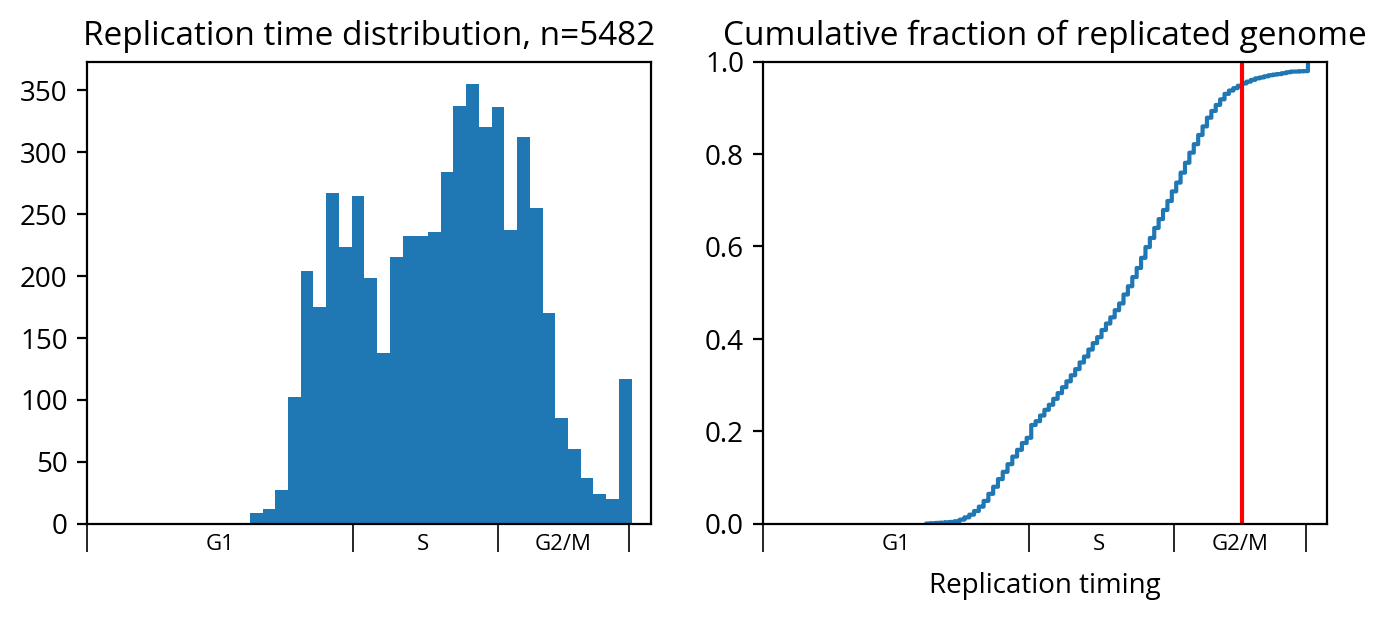

In [119]:
from src.config import load_default_chrom_configs, retrieve_phase_ticks

def set_tick_labels(ax, branch):
    config1, config2 = load_default_chrom_configs()
    phase_ticks, edge_ticks = retrieve_phase_ticks(branch, config1, config2)

    ax.set_xticks(phase_ticks)
    ax.set_xticklabels(['G1', 'S', 'G2/M'], fontsize=8)
    ax.set_xticks(edge_ticks, minor=True)
    ax.tick_params(axis='x', which='major', length=0)
    ax.tick_params(axis='x', which='minor', length=10) 

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.hist(replication_times.values, bins=30)
plt.title(f"Replication time distribution, n={len(replication_times)}")
set_tick_labels(plt.gca(), 't')

timings = np.sort(np.asarray(replication_times.values))
cum = np.arange(1, len(timings) + 1) / len(timings)

plt.subplot(1, 2, 2)
plt.plot(timings, cum, drawstyle='steps-post')
plt.xlabel('Replication timing')
plt.title("Cumulative fraction of replicated genome")
plt.ylim(0, 1)
set_tick_labels(plt.gca(), 't')

trep95 = np.quantile(replication_times.values, q=0.95)
plt.axvline(trep95, c='red')

retrieve -31.0


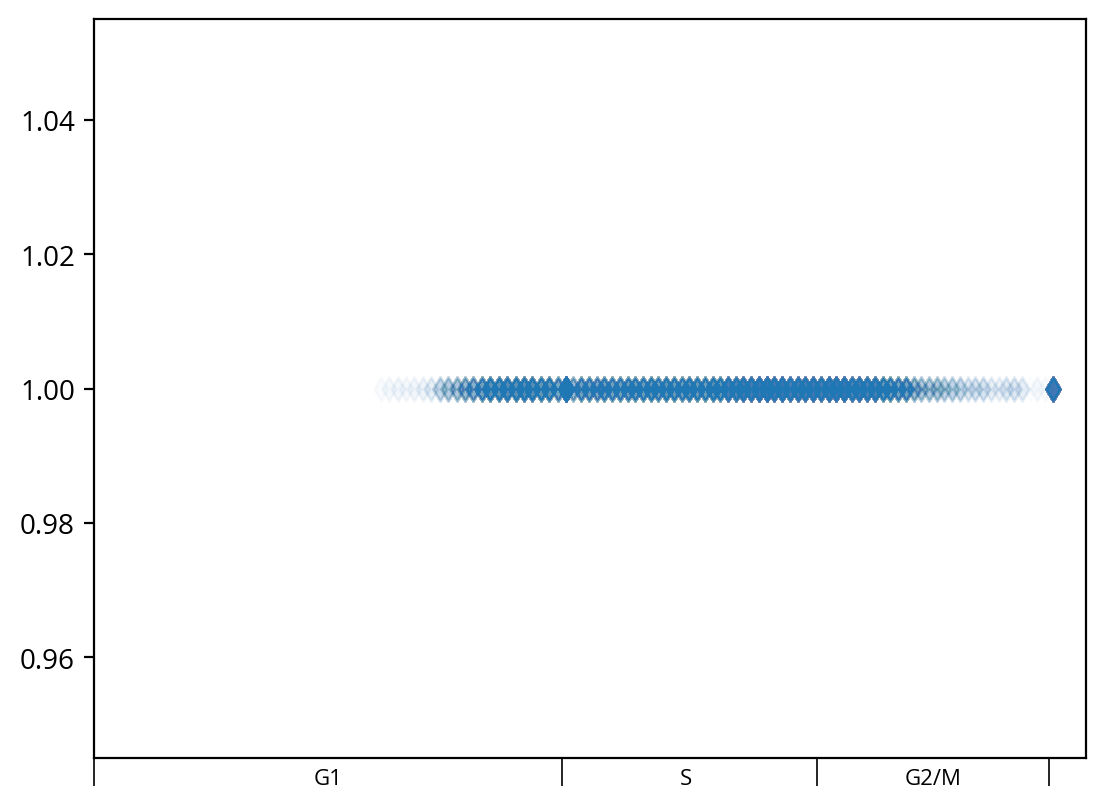

In [111]:
plt.scatter(replication_times.values, np.ones(len(replication_times)), alpha=0.01, marker='d')
set_tick_labels(plt.gca(), 't')

In [47]:
# fig_origins.layout_footprint_supplemental_panel()
# display(Image('output/draft4_run/Figures/Debug/Supplemental4.3_footprints_debug.png'))

In [48]:
# from src.replication_timing import ReplicationTiming
# repl_timing = ReplicationTiming('output/draft4_run/')

In [49]:
# fig_origins.plot_footprint_all_branches()